#Zaman Serisi

Geçmişteki verilerden geleceğe yönelik tahminler çıkarma

### 1. Kütüphaneleri yükle

In [6]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Zaman Serisi Analizi ve Tahminleme

* SARIMAX: Mevsimsellik ve dışsal faktörleri (reklam harcamaları, tatiller vb.) hesaba katarak geleceğe yönelik zaman serisi tahminleri yapan gelişmiş bir istatistiksel modeldir.
* STL: Bir zaman serisi verisini üç ana bileşene ayırır: Trend (genel eğilim), Mevsimsellik (tekrarlayan hareketler) ve Artık/Gürültü (rastgele dalgalanmalar). Veriyi anlamayı kolaylaştırır.
* adfuller (Augmented Dickey-Fuller testi): Verinin durağan (stationary) olup olmadığını test eder. Zaman serisi modellerinin (SARIMAX gibi) doğru çalışması için verinin istatistiksel özelliklerinin zamanla değişmemesi (durağan olması) gerekir.

### 2. Veri Setinin Yüklenmesi
Adidas Firmasına ait bir mağazanın satış verisi

In [7]:
data_url=r"https://github.com/nesicn/ecs-course/raw/main/data/adidas-quarterly-sales.csv"

In [8]:
df=pd.read_csv(data_url)
df.head()

,Time Period,Revenue
0,2000Q1,1517
1,2000Q2,1248
2,2000Q3,1677
3,2000Q4,1393
4,2001Q1,1558


###3. Veri Ön işleme-Keşifsel Veri Analizi

In [9]:
df.tail()

,Time Period,Revenue
83,2020Q4,5142
84,2021Q1,5268
85,2021Q2,5077
86,2021Q3,5752
87,2021Q4,5137


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Time Period  88 non-null     object
 1   Revenue      88 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.5+ KB


In [11]:
df['Revenue'].describe()

,Revenue
count,88.000000
mean,3302.034091
std,1477.855719
min,1078.000000
25%,1864.250000
50%,3162.000000
75%,4457.500000
max,6410.000000


In [12]:
# indexi ayarlama
df.index=pd.PeriodIndex(df['Time Period'], freq='Q').to_timestamp()
df.drop('Time Period', axis=1, inplace=True)
df

,Revenue
Time Period,
2000-01-01,1517
2000-04-01,1248
2000-07-01,1677
2000-10-01,1393
2001-01-01,1558
...,...
2020-10-01,5142
2021-01-01,5268
2021-04-01,5077


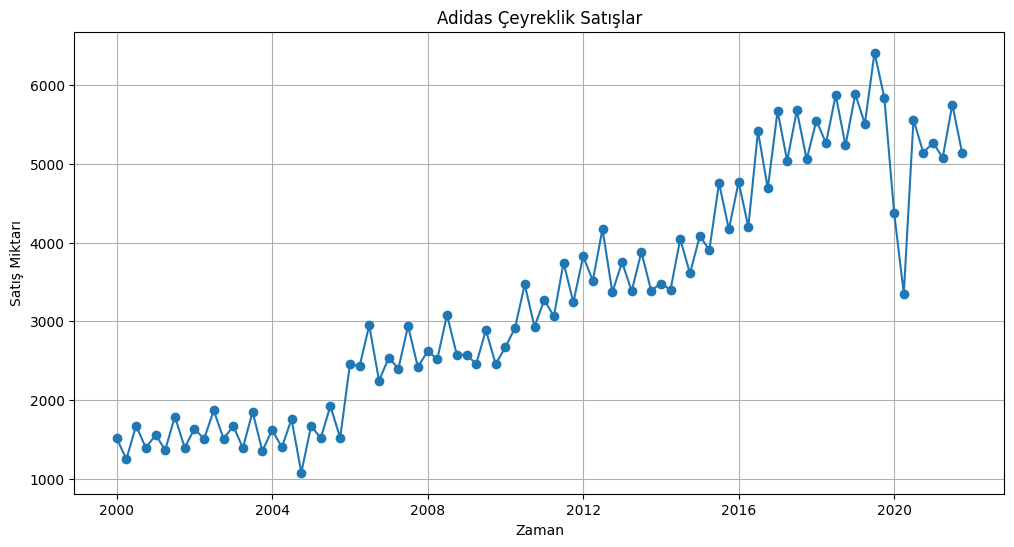

In [13]:
# veri görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df.index,df['Revenue'],marker='o')
plt.title("Adidas Çeyreklik Satışlar")
plt.xlabel("Zaman")
plt.ylabel("Satış Miktarı")
plt.grid(True)
plt.show()

Zaman serisi, düzenli çeyreklik mevsimsellik barındıran ve uzun vadede yukarı yönlü bir trend izleyen satış verilerini yansıtıyor.

**2020'deki Sert Düşüşün Nedenleri:**
* **COVID-19 Pandemisi:** 2020'nin ilk çeyreklerine denk gelen eşi görülmemiş kırılma, pandeminin yarattığı küresel şok etkisidir.
* **Fiziksel Mağaza Kapanmaları:** Karantina uygulamaları, perakende satış noktalarının kapanmasına ve satış hacminin aniden daralmasına yol açmıştır.
* **Tedarik Zinciri Krizi:** Üretim tesislerindeki duruşlar ve global lojistik ağlarındaki kesintiler ürün tedariğini vurmuştur.
* **Talep Şoku:** Tüketicilerin evde kalmasıyla spor ve günlük giyim gibi zorunlu olmayan harcama kalemlerindeki ani düşüştür.

**Diğer Yapısal Gözlemler:**
* **Mevsimsellik:** Yıl içindeki periyodik zirveler ve dipler, tatil dönemleri (yılsonu alışverişleri) veya belirli çeyreklerdeki yeni sezon lansmanlarıyla örtüşen düzenli varyasyonlardır.
* **2008-2009 Etkisi:** 2008 Küresel Finans Krizi'nin yarattığı durgunluk, o dönemdeki satışların yatay seyretmesi ve büyüme ivmesinin kaybolmasıyla okunabiliyor.
* **V Tipi Toparlanma:** 2020'deki dibin hemen ardından gelen çok sert yükseliş, e-ticaret altyapısına yönelimin artması ve kısıtlamaların kalkmasıyla patlayan "ertelenmiş talep" (pent-up demand) kaynaklıdır.

### 4. Trend, Mevsimsellik ve Artık (T,S,R)

Trend: Genel eğilim

Mevsimsellik: Belirli periyotlardaki düzenli tekrarlayan dalgalanmalar

Artık: Trend ve mevsimsellikten arındırılmış veride kalan gürültü

In [14]:
stl=STL(df['Revenue'],period=4)
result=stl.fit()

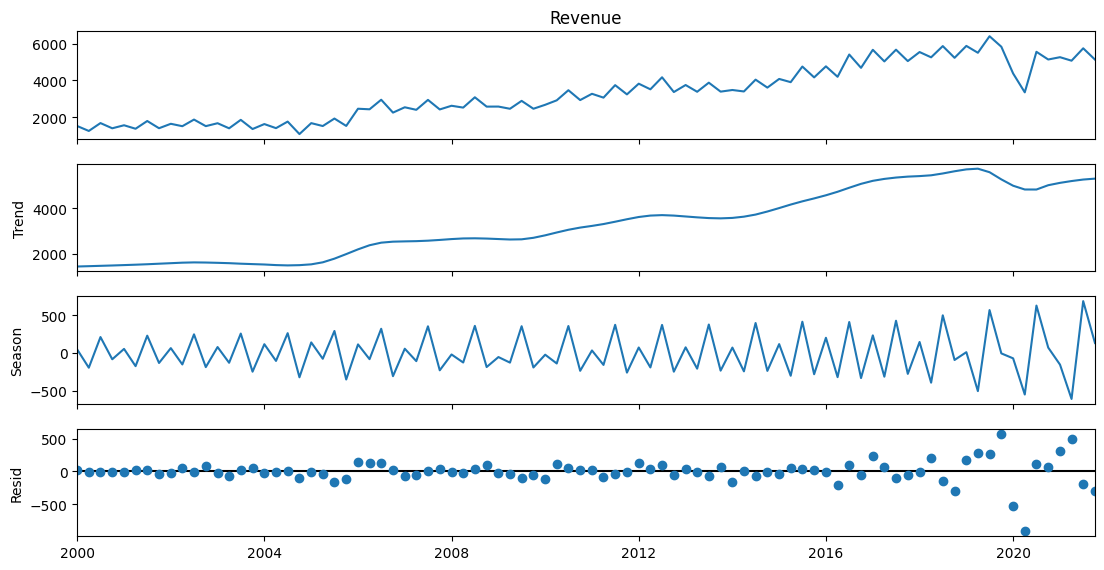

In [15]:
# sonuçları göster
fig=result.plot()
fig.set_size_inches(12,6)
plt.show()

**Trend (Eğilim):**
2000-2019 yılları arasında genel olarak pozitif yönlü ve istikrarlı bir büyüme mevcut. 2020 yılında dışsal bir şok (muhtemelen COVID-19) kaynaklı keskin bir yapısal kırılma/düşüş ve ardından toparlanma fazı görülüyor.

**Season (Mevsimsellik):**
Belirgin ve düzenli bir periyodiklik var. Ancak mevsimsel dalgalanmaların genliği (amplitude) zaman ilerledikçe (özellikle 2018 sonrasında) artmış. Grafikteki bu genişleme, seriye *additive* (toplamsal) ayrıştırma uygulandığına işaret ediyor;

**Resid (Kalıntılar-Artıklar):**
2016 öncesinde kalıntıların varyansı düşük ve sıfır etrafında nispeten rastgele dağılıyor. Ancak 2020 çevresinde heteroskedastisite (artan varyans) ve büyük aykırı değerler (outliers) göze çarpıyor. Mevcut ayrıştırma modeli, 2020'deki anomalinin yarattığı şoku trend veya mevsimsellik ile açıklayamamış ve bunu hata terimine yansıtmış.

### 5. İstatistiksel Modelin Kurulması
1. Uygunluk analizleri yapılmalı
2. trend ve mevsimsellik olduğu için **durağan olmama durumu** ortadan kaldırmalıyız.
3. ARIMA-SARIMA için durağanlık şartı var.

In [16]:
# eksik veri olsaydı bu şekilde durağanlaştırırdık
df['Rev_diff']=df['Revenue'].diff().dropna()

In [17]:
# durağanlık testi
adf_result_diff=adfuller(df['Rev_diff'].dropna())
adf_result_diff

(-4.3784483201342725,
 0.00032401497959918233,
 6,
 80,
 {'1%': np.float64(-3.5148692050781247),
  '5%': np.float64(-2.8984085156250003),
  '10%': np.float64(-2.58643890625)},
 np.float64(1092.5460597103142))

In [18]:
# p değeri ile kontrol
adf_output_diff={'ADF İstatistik Test Değeri:': adf_result_diff[0],
                 'p değeri:': adf_result_diff[1],
                 'Kritik değerler:': adf_result_diff[4]}

In [19]:
adf_output_diff

{'ADF İstatistik Test Değeri:': -4.3784483201342725,
 'p değeri:': 0.00032401497959918233,
 'Kritik değerler:': {'1%': np.float64(-3.5148692050781247),
  '5%': np.float64(-2.8984085156250003),
  '10%': np.float64(-2.58643890625)}}

**2022 Q1 (1. Çeyrek) Adidas Gelirini Tahmin Ettiğimizi Varsayalım:**

**`order=(p, d, q)` — Kısa Vadeli (Çeyrekten Çeyreğe) Etki**

Modele, hedeften hemen önceki ardışık dönemleri nasıl kullanacağını söyler.

* **`p=1` (AutoRegressive):** 2022 Q1 gelirini tahmin ederken, hemen bir önceki çeyreğe (2025 Q4) ne kadar bağımlı olduğuna bakar. *Örnek:* 2021 Q4'teki yılbaşı satış ivmesi, 2022 Q1'e nasıl bir rüzgar taşıyacak?
* **`d=1` (Differencing):** Toplam geliri değil, çeyrekten çeyreğe olan "büyüme miktarını" tahmin eder. Şirketin yıllara yayılan genel büyüme trendini (enflasyon, organik büyüme) seriden çıkarır.
* **`q=1` (Moving Average):** 2021 Q4 için yapılan tahmin ile gerçekleşen satış arasındaki "hataya (şok)" odaklanır. *Örnek:* Q4'te tedarik zinciri koptuğu için model yanıldıysa ve satışlar beklenenden 200 Milyon € az geldiyse, Q1 tahminini bu yakın tarihli negatif şoku hesaba katarak aşağı yönlü düzeltir.

---

**`seasonal_order=(P, D, Q, s)` — Mevsimsel (Yıldan Yıla) Etki**
Modele, hedef dönemin "geçmiş yıllardaki aynı dönemleriyle" ilişkisini nasıl kuracağını söyler.

* **`s=4` (Seasonality):** Finansal veri çeyreklik (quartile) olduğu için mevsimsel döngü 4'tür. Model geçmişe 4'er adım (1 yıl) atlayarak bakar.
* **`P=1` (Seasonal AR):** 2022 Q1'i tahmin ederken, doğrudan geçen yılın aynı dönemine (2021 Q1) bakar. *Örnek:* İlkbahar/Yaz koleksiyonlarının piyasaya çıkış dinamikleri her Q1'de benzer karakter gösterir, bu yüzden geçen yılın Q1 rakamları temel alınır.
* **`D=1` (Seasonal Differencing):** Çeyrekler arası yapısal eşitsizliği siler (Örn: Q4 Black Friday yüzünden daima Q1'den yüksektir). 2022 Q1 geliri ile 2021 Q4 gelirini kıyaslamak yerine, **2022 Q1 ile 2021 Q1** arasındaki farka (Yıllıklandırılmış/Year-over-Year büyümeye) odaklanır.
* **`Q=1` (Seasonal MA):** Doğrudan geçen yılın aynı çeyreğindeki (2021 Q1) tahmin hatasına bakar. *Örnek:* 2021 Q1'de yeni bir ayakkabı serisi beklentilerin çok üzerinde satıp modele hata yaptırdıysa, 2022 Q1'de benzer bir dönemsel şok ihtimalini ağırlıklandırır.

**`enforce_stationarity=False` (Durağanlık Dayatmasını Esnet)**
* **Teorik Anlamı:** Statsmodels, AR (Otoregresif) parametreleri hesaplanırken denklemin köklerinin birim çemberin dışında kalmasını (katı bir durağanlık şartı) bekler.
* **Somut Durum:** Sen `d=1` vererek veriyi durağanlaştırmaya çalıştın ama gerçek dünya verilerinde (örneğin gelir tablosunda) her zaman kusursuz bir durağanlık sağlanamaz. Bu parametre `True` (varsayılan) kalırsa, arka plandaki optimizasyon algoritması (L-BFGS vb.) matematiksel sınıra çarptığı an ya hata fırlatır ya da yakınsamayı durdurur.
* **Sonuç:** `False` diyerek modele şunu söylersin: *"Veri tam durağanlık sınırlarına uymasa bile hata verme, esnek davran ve eldeki durum için en iyi parametreyi (Loss fonksiyonunu minimize eden değeri) bulmaya devam et."*

**`enforce_invertibility=False` (Tersine Çevrilebilirlik Dayatmasını Esnet)**
* **Teorik Anlamı:** MA (Hareketli Ortalama) bileşeninin geçmiş hata terimlerinden geriye dönük olarak kesin bir şekilde hesaplanabilmesi (invertible) şartıdır.
* **Somut Durum:** Optimizasyon algoritması en düşük hatayı ararken geniş bir sayı uzayını tarar. Bazen hata oranını düşüren en iyi katsayılar, bu "tersine çevrilebilirlik" sınırının dışında kalabilir. Model bu sınıra katı katıya bağlı kalırsa, daha iyi bir tahmin gücüne sahip olacak katsayıları es geçer.
* **Sonuç:** `False` diyerek optimizasyon alanını genişletirsin. Algoritma, teorik kısıtlamalara takılmadan daha geniş bir parametre uzayında özgürce dolaşır, bu da modelin daha hızlı eğitilmesini ve yerel minimumlara (local minima) takılmamasını sağlar.

**Özetle:** İkisi de modeli teorik prangalardan kurtarıp, gerçek dünya verisine "ne pahasına olursa olsun en iyi tahmini uydurması" için optimizasyon algoritmasına verilen esneklik (bypass) yetkileridir.

In [20]:
# model oluşturma
model_sarimax=SARIMAX(df['Revenue'],
                      order=(1,1,1),
                      seasonal_order=(1,1,1,4),
                      enforce_stationarity=False,
                      enforce_invertibility=False)

In [21]:
# modeli eğit
sarimax_result=model_sarimax.fit()

### 6. Modelin Değerlendirilmesi (Tahmin-Değerlendirme)

In [22]:
# mevcut satışları tahmin
df['Forecast']=sarimax_result.fittedvalues

In [23]:
# gerçek ve tahminleri karşılaştır
df[['Revenue','Forecast']]

,Revenue,Forecast
Time Period,,
2000-01-01,1517,0.000000
2000-04-01,1248,1871.719794
2000-07-01,1677,1266.664326
2000-10-01,1393,1841.702139
2001-01-01,1558,2333.577472
...,...,...
2020-10-01,5142,5144.409553
2021-01-01,5268,5264.246650
2021-04-01,5077,4844.383606


<Axes: xlabel='Time Period'>

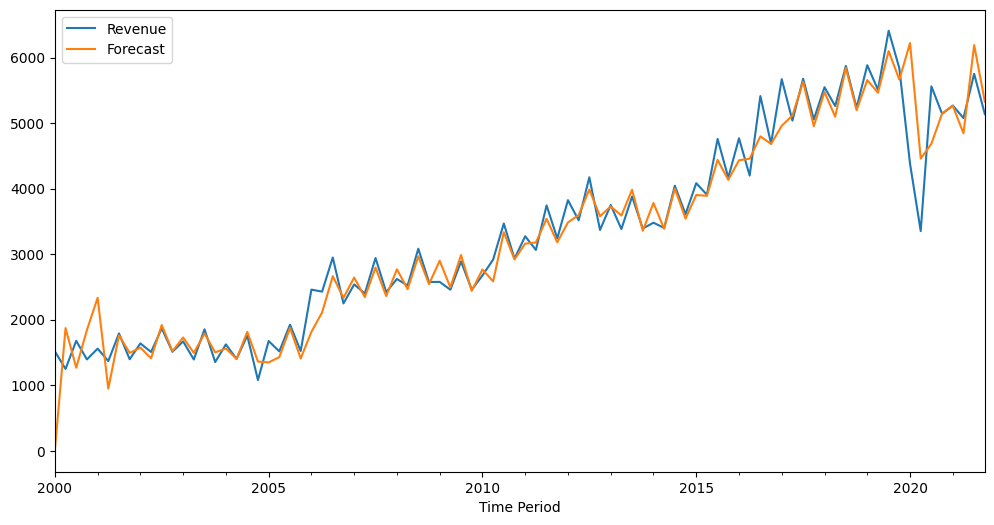

In [24]:
df[['Revenue','Forecast']].plot(figsize=(12,6))

grafiğin ilk verisi önceki verilere dayalı modelleme mantığından dolayı sıfırdan başlıyor. bu düzeltilmeli

##Metriklerle Modelin Değerlendirlmesi

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ilk değer 0 olduğu için metrik hesaplamasından hariç tutuyoruz
actual = df['Revenue'][1:]
predicted = df['Forecast'][1:]

mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"Ortalama Mutlak Hata (MAE): {mae:.2f}")
print(f"Ortalama Kare Hata (MSE): {mse:.2f}")
print(f"Kök Ortalama Kare Hata (RMSE): {rmse:.2f}")
print(f"Ortalama Mutlak Yüzde Hata (MAPE): %{mape:.2f}")

Ortalama Mutlak Hata (MAE): 207.18
Ortalama Kare Hata (MSE): 118075.45
Kök Ortalama Kare Hata (RMSE): 343.62
Ortalama Mutlak Yüzde Hata (MAPE): %7.56


### 7. Gelecek 4 yıla ilişkin tahmin

Modeli işe yarar gördük ve öngörüsel tahminleri aldık

In [26]:
forecast=sarimax_result.get_forecast(steps=16) # 4 yıl yani gelecekteki 16 veri noktası
mean_forecast=forecast.predicted_mean # tahmini ortalama
conf_int=forecast.conf_int() # güven aralığı
lower_series=np.array(conf_int.iloc[:,0])
upper_series=np.array(conf_int.iloc[:,1])

In [27]:
lower_series

array([4768.02280505, 4328.46811548, 5244.61707832, 4684.3586144 ,
       4833.48690933, 4447.92885316, 5399.80947516, 4843.85939641,
       5006.52423106, 4621.06902297, 5571.86430393, 5012.84945552,
       5175.9236407 , 4789.26120129, 5738.75872457, 5178.48093769])

In [28]:
upper_series

array([6072.46569143, 5936.20590089, 6991.52277889, 6502.05763727,
       6788.914521  , 6475.16060764, 7466.50861271, 6933.21525159,
       7159.00166781, 6809.33705896, 7781.15364123, 7234.94289914,
       7447.58127846, 7089.99793524, 8057.05760137, 7507.74534373])

In [29]:
future_dates=pd.date_range(start=df.index[-1],
                           periods=16,
                           freq='Q')

In [30]:
future_dates

DatetimeIndex(['2021-12-31', '2022-03-31', '2022-06-30', '2022-09-30',
               '2022-12-31', '2023-03-31', '2023-06-30', '2023-09-30',
               '2023-12-31', '2024-03-31', '2024-06-30', '2024-09-30',
               '2024-12-31', '2025-03-31', '2025-06-30', '2025-09-30'],
              dtype='datetime64[ns]', freq='QE-DEC')

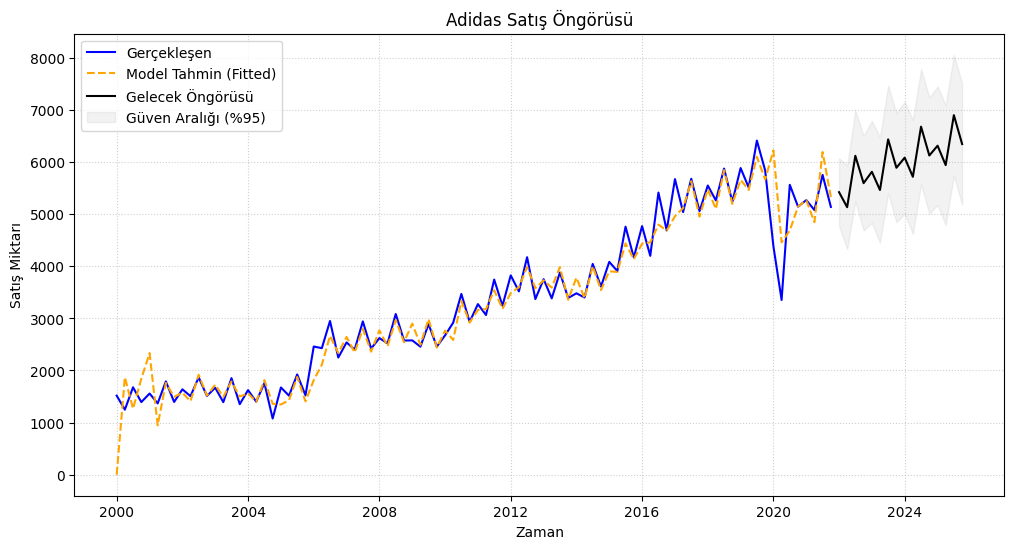

In [31]:
# Tahmin grafiği
plt.figure(figsize=(12, 6))

# Mevcut veriler ve modelin geçmiş tahmini
plt.plot(df.index, df['Revenue'], label='Gerçekleşen', color='blue')
plt.plot(df.index, df['Forecast'], label='Model Tahmin (Fitted)', linestyle='--', color='orange')

# Gelecek öngörüsü (marker kaldırıldı)
plt.plot(future_dates, mean_forecast, label='Gelecek Öngörüsü', color='black')

# Alt ve Üst sınırları (Güven Aralığı) göster
plt.fill_between(future_dates,
                 lower_series,
                 upper_series,
                 color='gray',
                 alpha=0.1,
                 label='Güven Aralığı (%95)')

# Markerlar (scatter plotlar) kaldırıldı

plt.title('Adidas Satış Öngörüsü')
plt.xlabel('Zaman')
plt.ylabel('Satış Miktarı')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 8. İş Analitiği ve Bulgular

*   **Trend ve Büyüme:** Adidas satışlarında 2000'den bu yana istikrarlı bir yükseliş trendi gözlemlenmektedir. Model, bu büyümenin devam edeceğini öngörmektedir.
*   **Mevsimsellik Etkisi:** Satışlarda belirgin bir çeyreklik döngü vardır. Özellikle yılın belirli dönemlerinde (grafikteki zirveler) talebin arttığı görülmektedir; bu, stok ve kampanya yönetimi için kritiktir.
*   **Model Performansı:** %7.56'lık MAPE değeri, modelin tahmin gücünün yüksek olduğunu ve stratejik kararlar için güvenilir bir temel sunduğunu göstermektedir.
*   **Anomali:** 2020 civarındaki sert düşüş (muhtemelen pandemi etkisi), modelin standart dışı dış etkenlere karşı hassasiyetini göstermektedir.

### 9. Modelin Geliştirilmesi (Yol Haritası)

Modeli daha hassas hale getirmek için şu adımlar izlenebilir:
1.  **Dışsal Değişkenler (SARIMAX):** Döviz kuru, enflasyon veya pazarlama harcamaları gibi dış veriler modele eklenebilir.
2.  **Hiperparametre Optimizasyonu:** `order` ve `seasonal_order` parametreleri deneme-yanılma (Grid Search) ile optimize edilebilir.
3.  **Alternatif Modeller:** Prophet veya derin öğrenme tabanlı LSTM modelleri ile karşılaştırma yapılabilir.

In [32]:
# Örnek: En iyi parametreleri (AIC kriterine göre) otomatik bulma yaklaşımı
import itertools

def evaluate_sarima(data, p, d, q, P, D, Q, s):
    try:
        mod = SARIMAX(data, order=(p,d,q), seasonal_order=(P,D,Q,s),
                     enforce_stationarity=False, enforce_invertibility=False)
        results = mod.fit(disp=False)
        return results.aic
    except:
        return float('inf')

print("Model geliştirme için en düşük AIC değerine sahip parametreler araştırılabilir.")

Model geliştirme için en düşük AIC değerine sahip parametreler araştırılabilir.
